# Reinforcement Learning

# 1. Dynamic Programming

This notebook presents some examples of Markov Decison Processes, where an **agent** interacts with its **environment** and collects **rewards**. 

The rewards are attached to the **states**. In games for instance, the reward of a state is +1 if we win, -1 if we loose, 0 in all other cases.

If the model is known and the state space is not too large, the optimal policy can be found by **dynamic programming** (policy iteration or value iteration).

In [1]:
import numpy as np

Each model is an object of the class ``Environment`` storing the current state. 

In [2]:
from model import Environment

In [3]:
methods_environment = [method for method in dir(Environment) if '__' not in method]

In [4]:
methods_environment

['decode',
 'display',
 'encode',
 'get_actions',
 'get_all_actions',
 'get_all_states',
 'get_model',
 'get_reward',
 'get_transition',
 'init_state',
 'is_game',
 'is_terminal',
 'reset',
 'show',
 'step']

The agent interacts with the environment and collects rewards.

In [5]:
from agent import Agent

In [6]:
methods_agent = [method for method in dir(Agent) if '__' not in method]

In [7]:
methods_agent

['get_action',
 'get_actions',
 'get_episode',
 'get_returns',
 'one_step_policy',
 'random_policy']

## Walk

We start with a walk in a square. Some states (to be found) have positive rewards. Some wind (unknown) disturbs the walk.

In [8]:
from model import Walk

In [9]:
# environment
model = Walk()

In [10]:
# state
model.state

array([0, 0])

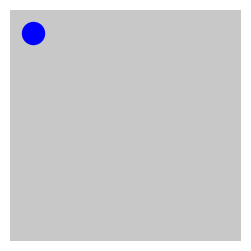

In [11]:
# display state
model.display()

In [12]:
# show state in plain text
model.show()

|O    |
|     |
|     |
|     |
|     |


In [13]:
# rewards (to be discovered)
model.Rewards

{(1, 1): 1, (1, 3): -1, (3, 1): -1, (3, 3): 3}

In [14]:
state = model.state

In [15]:
model.get_actions(state)

[(0, 1), (1, 0)]

In [16]:
action = (0, 1)

In [17]:
reward, stop = model.step(action)

In [18]:
reward

0

In [19]:
stop

False

In [20]:
# new state
model.state

array([0, 1])

In [21]:
model.show()

| O   |
|     |
|     |
|     |
|     |


In [22]:
# agent with random policy (default)
agent = Agent(model)

In [23]:
state = model.state

In [24]:
# all possible actions
agent.get_actions(state)

[(0, 1), (0, -1), (1, 0)]

In [25]:
# policy of the agent
probs, actions = agent.policy(state)

In [26]:
print(probs)

[0.33333333 0.33333333 0.33333333]


In [27]:
print(actions)

[(0, 1), (0, -1), (1, 0)]


In [28]:
# selected action
action = agent.get_action(state)

In [29]:
# action on the environment
model.step(action)

(0, False)

In [30]:
model.show()

|O    |
|     |
|     |
|     |
|     |


In [31]:
# an episode
stop, states, rewards = agent.get_episode(horizon=20)

In [32]:
# the episode includes the initial state
len(states)

21

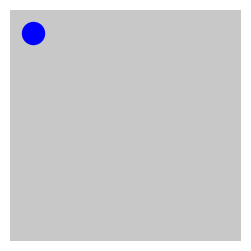

In [33]:
# display the episode
animation = model.display(states)

In [34]:
animation

In [35]:
# rewards
rewards

[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0]

In [36]:
len(rewards)

20

In [37]:
# returns for several episodes from the initial state, with discount factor
returns = agent.get_returns(n_episodes=10, horizon=100, gamma=0.9)

In [38]:
np.mean(returns)

np.float64(0.6797803207125586)

## Games

Now let's play games!<br>
Note that in most games:
* we play against an adversary (which is part of the environment),
* we may play first or second,
* when we adversary plays, WE have only one possible action (let our adversary play),
* we can also impose an action to we adversary (useful for training).

We here consider [Tic-Tac-Toe](https://en.wikipedia.org/wiki/Tic-tac-toe), [Nim](https://en.wikipedia.org/wiki/Nim), [Connect Four](https://en.wikipedia.org/wiki/Connect_Four) and [Five in a row](https://en.wikipedia.org/wiki/Gomoku).

In [39]:
from model import TicTacToe, Nim, ConnectFour, FiveInRow

Each game is an object of the class ``Game``. 

In [40]:
from model import Game

In [41]:
methods_game = [method for method in dir(Game) if '__' not in method]

In [42]:
methods_game

['Board_Size',
 'decode',
 'display',
 'encode',
 'get_actions',
 'get_all_actions',
 'get_all_states',
 'get_available_actions',
 'get_model',
 'get_next_state',
 'get_reward',
 'get_transition',
 'init_state',
 'is_game',
 'is_terminal',
 'reset',
 'show',
 'step']

The method ``get_next_state`` allows we to get the next state for any (state, action) pair, without modifying the current state. This will be useful to learn good policies.

The method ``get_available_actions`` gives the available actions, ignoring the player.

In [43]:
set(methods_game) - set(methods_environment)

{'Board_Size', 'get_available_actions', 'get_next_state'}

We play Tic-Tac-Toe. 

In [44]:
Game = TicTacToe

### Random players

In [45]:
# game against a random player (default)
game = Game()

In [46]:
game.show()

|   |
|   |
|   |


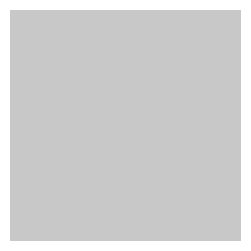

In [47]:
game.display()

In [48]:
# next player, board
game.state

(1,
 array([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]))

In [ ]:
# our possible actions
game.get_actions(game.state)

[(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]

In [50]:
# random player (default)
agent = Agent(game)

In [51]:
state = game.state
action = agent.get_action(state)

In [52]:
action

(2, 2)

In [54]:
reward, stop = game.step(action)

In [55]:
game.show()

|   |
|   |
|  O|


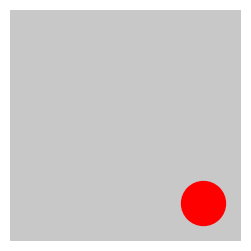

In [ ]:
# we're blue
game.display()

In [57]:
game.state

(1,
 array([[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0, -1]]))

In [58]:
# all possible moves
game.get_actions(game.state)

[(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1)]

In [ ]:
# our moves (not our turn)
agent.get_actions(game.state)

[(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1)]

In [60]:
action = agent.get_action(game.state)

In [61]:
print(action)

(0, 2)


In [62]:
reward, stop = game.step(action)

In [63]:
game.show()

|  X|
|   |
|  O|


In [64]:
stop, states, rewards = agent.get_episode()

In [65]:
game.show()

|XOX|
|XOO|
|OXX|


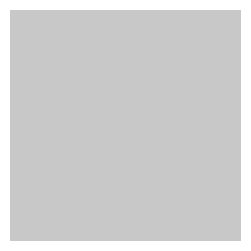

In [66]:
animation = game.display(states)

In [67]:
animation

In [68]:
rewards

[0, 0, 0, 0, 0, 0, 0, 0, 0]

In [69]:
returns = agent.get_returns()
np.unique(returns, return_counts=True)

(array([-1,  0,  1]), array([32, 17, 51]))

### One step policy

In [70]:
# your adversary is random
game = Game()

In [ ]:
# we play with one-step ahead policy
agent = Agent(game, policy='one_step')

In [72]:
stop, states, rewards = agent.get_episode()

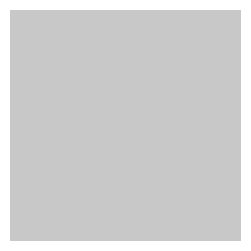

In [73]:
animation = game.display(states)

In [74]:
animation

In [75]:
returns = agent.get_returns()
np.unique(returns, return_counts=True)

(array([0, 1]), array([ 5, 95]))

In [ ]:
# our adversary also looks one-step ahead
game = Game(adversary_policy='one_step')

In [77]:
agent = Agent(game, policy='one_step')

In [78]:
stop, states, rewards = agent.get_episode()

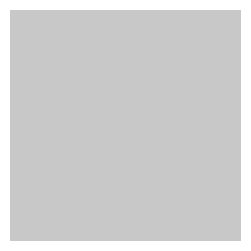

In [79]:
animation = game.display(states)

In [80]:
animation

In [81]:
returns = agent.get_returns()
np.unique(returns, return_counts=True)

(array([-1,  0,  1]), array([13, 50, 37]))

## Value function

The value function of a policy can be computed from Bellman's equation, provided the state space is not too large.

In [82]:
from dynamic import PolicyEvaluation, PolicyIteration, ValueIteration

We start with the walk.

In [83]:
model = Walk()
agent = Agent(model)
random_policy = agent.policy

In [84]:
gamma = 0.9
algo = PolicyEvaluation(model, random_policy, gamma=gamma)

In [85]:
algo.evaluate_policy()

In [86]:
values = algo.values

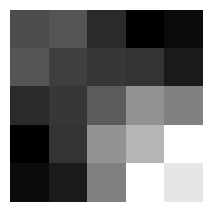

In [87]:
model.display_values(values)

In [88]:
# average return
returns = agent.get_returns(gamma=gamma)
print(np.mean(returns))

0.8559257941995068


In [89]:
# the value of a state is the expected gain
state = model.init_state()
i = algo.get_state_id(state)
print(algo.values[i])

0.8486455585974576


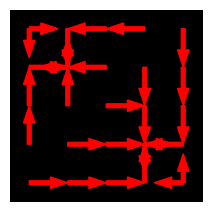

In [90]:
# improved policy
policy = algo.improve_policy()
model.display_policy(policy)

## To do

Answer the following questions:
* Is the improved policy optimal?
* Which return can be expected from the initial state?

We can check the rewards in this environment.

No, the improved policy is not optimal.

From the initial state, the improved policy goes to the nearby reward state `(1,1)`, which gives reward `+1`, and then keeps oscillating around it to collect this reward every other step. With `γ = 0.9`, the expected return is therefore:

$$
0 + \gamma + 0 + \gamma^3 + 0 + \gamma^5 + \cdots
= \frac{\gamma}{1-\gamma^2}
= \frac{0.9}{1-0.9^2}
\approx 4.74
$$

So the expected return from the initial state is about **4.74**.

This policy is not optimal because a better long-term strategy is to go to the state `(3,3)`, which gives reward `+3`. That yields a larger return, about **10.22** from the initial state.


In [91]:
model.Rewards

{(1, 1): 1, (1, 3): -1, (3, 1): -1, (3, 3): 3}

## Policy Iteration

In general, several iterations are necessary to get the optimal policy.

In [92]:
algo = PolicyIteration(model, gamma=gamma)
policy = algo.get_optimal_policy()

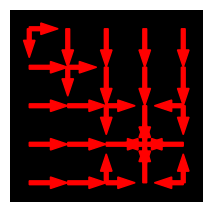

In [93]:
model.display_policy(policy)

In [94]:
# new value
state = model.init_state()
i = algo.get_state_id(state)
print(algo.values[i])

10.223148864331598


## Value Iteration

The optimal value function can be found directly by value iteration.

In [95]:
algo = ValueIteration(model, gamma=gamma)
policy = algo.get_optimal_policy()

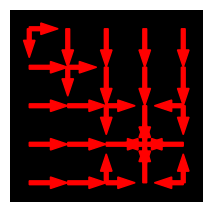

In [96]:
model.display_policy(policy)

In [97]:
# new value
state = model.init_state()
i = algo.get_state_id(state)
print(algo.values[i])

10.223148864331598


## To do

* We play TicTacToe at random we play perfectly against the same adversary. What is our first move?
* What is the outcome of the game between two perfect players?
* Do the same for Nim.

In [98]:
def initial_value(algo, game):
    state = game.init_state()
    i = algo.get_state_id(state)
    return float(algo.values[i])


def best_initial_actions(algo, game):
    state = game.init_state()
    i = algo.get_state_id(state)
    actions = game.get_actions(state)
    next_values = algo.rewards + algo.gamma * algo.values
    values = np.array([algo.transitions[action].dot(next_values)[i] for action in actions], dtype=float)
    best_value = np.max(values)
    return [action for action, value in zip(actions, values) if np.isclose(value, best_value)]


def analyze_game(Game, horizon):
    game = Game(adversary_policy='one_step')
    algo = PolicyEvaluation(game, policy='random', gamma=1, n_eval=horizon)
    algo.evaluate_policy()
    random_gain = initial_value(algo, game)

    algo = ValueIteration(game, gamma=1, n_iter=horizon)
    algo.get_optimal_policy()
    perfect_gain = initial_value(algo, game)
    first_moves = best_initial_actions(algo, game)

    perfect_game = Game()
    algo = ValueIteration(perfect_game, gamma=1, n_iter=horizon)
    algo.get_perfect_players()
    perfect_vs_perfect = initial_value(algo, perfect_game)

    return {
        'random_vs_one_step': random_gain,
        'perfect_vs_one_step': perfect_gain,
        'best_first_moves': first_moves,
        'perfect_vs_perfect': perfect_vs_perfect,
    }


tictactoe_results = analyze_game(TicTacToe, horizon=9)
nim_results = analyze_game(Nim, horizon=16)

print('TicTacToe')
print('random vs one-step:', round(tictactoe_results['random_vs_one_step'], 4))
print('perfect vs one-step:', round(tictactoe_results['perfect_vs_one_step'], 4))
print('best first move(s):', tictactoe_results['best_first_moves'])
print('perfect vs perfect:', tictactoe_results['perfect_vs_perfect'])
print()
print('Nim')
print('random vs one-step:', round(nim_results['random_vs_one_step'], 4))
print('perfect vs one-step:', round(nim_results['perfect_vs_one_step'], 4))
print('best first move(s):', nim_results['best_first_moves'])
print('perfect vs perfect:', nim_results['perfect_vs_perfect'])

TicTacToe
random vs one-step: -0.6388
perfect vs one-step: 0.9271
best first move(s): [(0, 0), (0, 2), (2, 0), (2, 2)]
perfect vs perfect: 0.0

Nim
random vs one-step: 0.0
perfect vs one-step: 1.0
best first move(s): [(0, 1), (1, 1), (2, 1), (3, 1)]
perfect vs perfect: -1.0


## Answers

For **TicTacToe**, playing at random against the one-step adversary gives an expected gain of about **-0.639**. If we
play perfectly against the same adversary, the expected gain becomes about **0.927**. The best first move is **a corner**: `(0,0)`, `(0,2)`, `(2,0)` or `(2,2)`. Between two perfect players, the outcome is **0**, so the game ends in **a draw**.

For **Nim**, playing at random against the one-step adversary gives an expected gain of **0**. If we play perfectly against the same adversary, the expected gain is essentially **1**, so we can force a win. A best first move is to **remove one object from any row**, i.e. `(0,1)`, `(1,1)`, `(2,1)` or `(3,1)`. Between two perfect players, the outcome is **-1**, so **the first player loses** from the initial position.

